# Mapping the Potential Destructive Power of Wildfires Using Machine Learning
---
## Module 4: *Variable Selection*
##### Version Number: 2.0
---
### Contents  
> 1. *Water Demand*
> 2. *Water Supply*
> 3. *Water Supply Indexes*
> 4. *Fire Danger Indicators*
> 5. *Social Variables*
> 6. *Temporal and Geographic Varaibles*
> 7. *Export File*
---
### Notes
- This module visualizes key variables to assess their relationships with wildfire severity categories. Based on the `Categorical` target, we explore how different weather features interact and correlate with fire risk.
---
### Inputs
- `engineered_samples.csv` engineered and cleaned samples data with weather, fire, and grid data.
---
### Outputs 
- `X`,`y`,`details` - Split training data filtered from 2018 to 2024
- `pal_x`, `pal_y`, `pal_details` - Split training data from 2025 for case study
---
### User Defined Dependencies

In [ ]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

# Function to print a grid of kde plots in consistent format, adjusts columns and rows accordingly
from src.plot_utils import grid_kde

# Function to print a custom format correlation heatmap
from src.plot_utils import correlation_map

# Function to print simple bar charts side by side
from src.plot_utils import bar_group

---
### Third Party Dependencies

In [2]:
# Core data tools
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set consistent plotting style
sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

---

### Loading Data

In [ ]:
samples = pd.read_csv('../data/processed/engineered_samples.csv')

#### Encode regional text descriptions for modeling 

In [4]:
samples['province_code'], uniques = pd.factorize(samples['dominant_province_description'])
samples['section_code'], uniques = pd.factorize(samples['dominant_section_description'])

---

## Filter Dates for modeling

- **01/01/2018 - 12/31/2024** Dates to train the models
- **01/01/2025 - 01/23/2025** Dates for evaluating model performance on unseen data

In [6]:
samples['Date'] = pd.to_datetime(samples['Date'])

# first day to analyze in weather dataset
FIRST_DATE = pd.to_datetime('2018-01-01').date()

# last day to analyze in weather dataset
LAST_DATE = pd.to_datetime('2024-12-31').date()

# Boolean mask for dates within the range
mask = (samples['Date'].dt.date >= FIRST_DATE) & (samples['Date'].dt.date <= LAST_DATE)

pal = samples.loc[~mask]

# Keep only rows within the range
samples = samples.loc[mask].copy()

## Split datasets for analysis and modeling

In [7]:
# Columns to drop for feature interaction analysis
text_columns = ['Sample_ID', 'Date','Target', 'grid_id', 'centroid_easting', 'centroid_northing',
       'geometry', 'fire_count', 'total_fire_damage','acres',  'dominant_section_description',
                'dominant_province_description','maximum_x', 'minimum_y',
       'maximum_y', 'minimum_x','area_in_cali']

y = samples['Target']
X = samples.drop(columns=text_columns)
details = samples[text_columns]
details = details.drop(columns = 'Target')

pal_details = pal[text_columns]
pal_X = pal.drop(columns=text_columns)
pal_y = pal['Target']

## Winsorize (Optional)

winsor = X.copy()

for col in winsor.select_dtypes(include=[np.number]).columns:
    Q1 = winsor[col].quantile(0.25)
    Q3 = winsor[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR

    # Winsorize (cap values)
    winsor[col] = np.clip(winsor[col], lower, upper)
    
X = winsor

In [8]:
filtered = X
filtered['Target'] = y

## 1. DIrect Water Demand Indicators

In [ ]:
water_demand = [
    "Actual Evapotranspiration",
    "Solar Radiation",
    "Daily Minimum Air Temperature",
    "Daily Maximum Air Temperature",
    "Vapor Pressure Deficit",
    "Wind Speed",
    "Target"
]

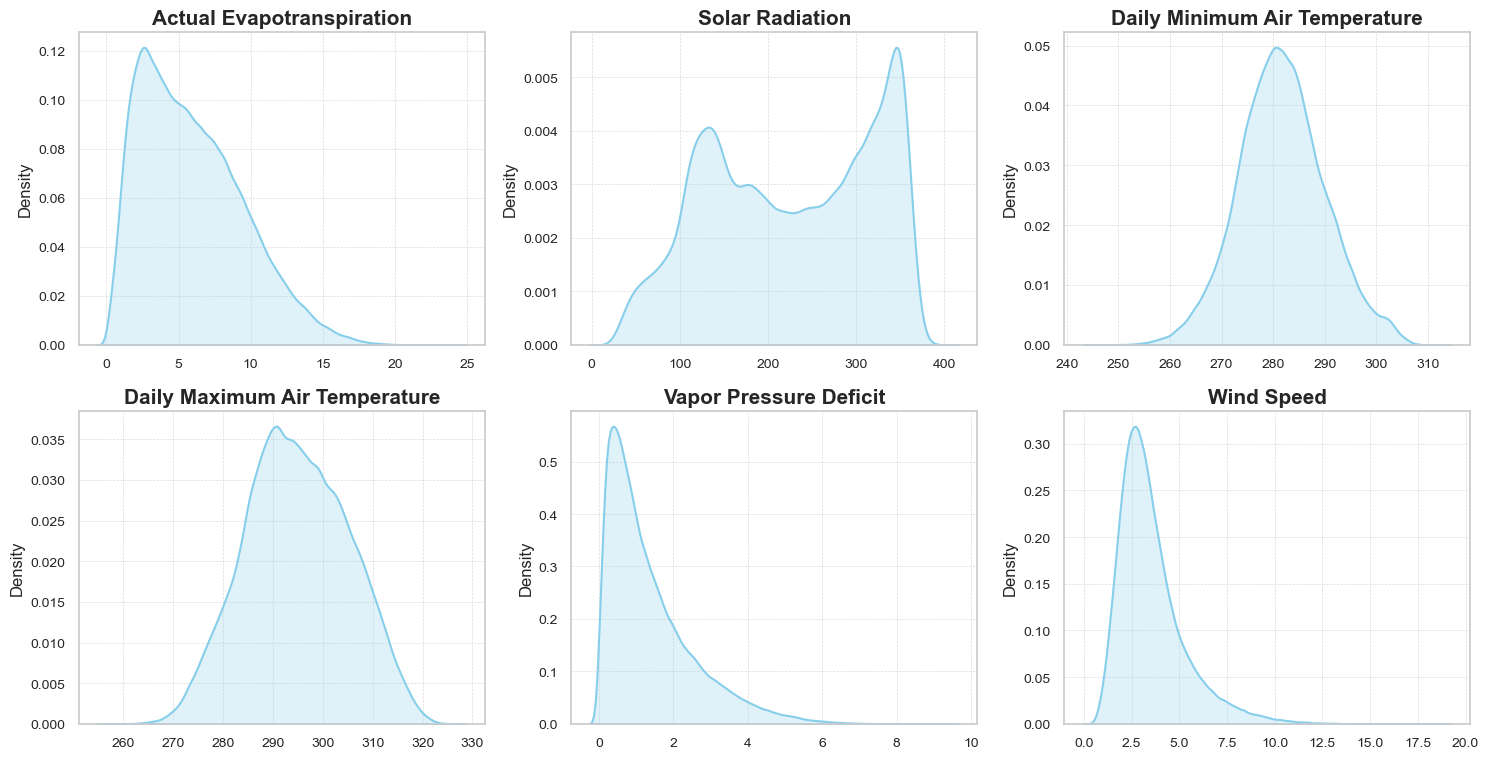

In [ ]:
grid_kde(filtered[water_demand].drop(columns='Target'))

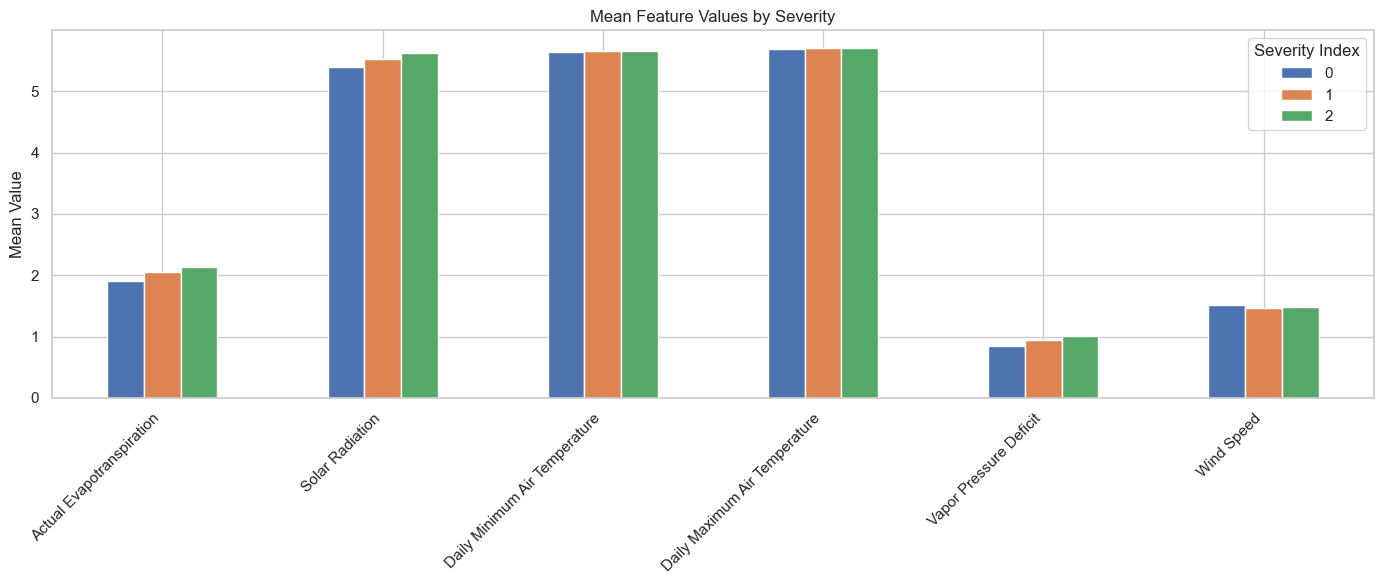

In [10]:
bar_group(filtered[water_demand])

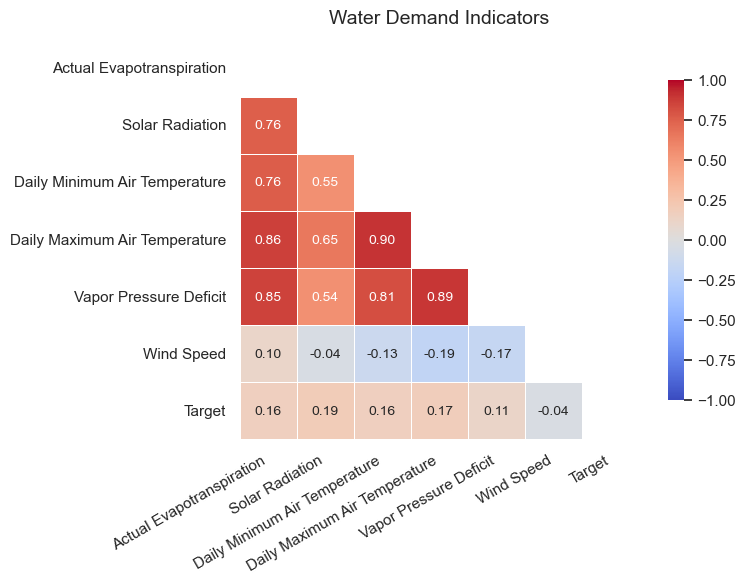

In [11]:
correlation_map(filtered[water_demand],'Water Demand Indicators')

In [12]:
drop = ['']

---

## 3. Water Supply Indicators

In [ ]:
water_supply = [
    "Precipitation",
    "Maximum Relative Humidity",
    "Minimum Relative Humidity",
    "Specific Humidity",
    "100-hour Dead Fuel Moisture",
    "1000-hour Dead Fuel Moisture",
    'Target'
]

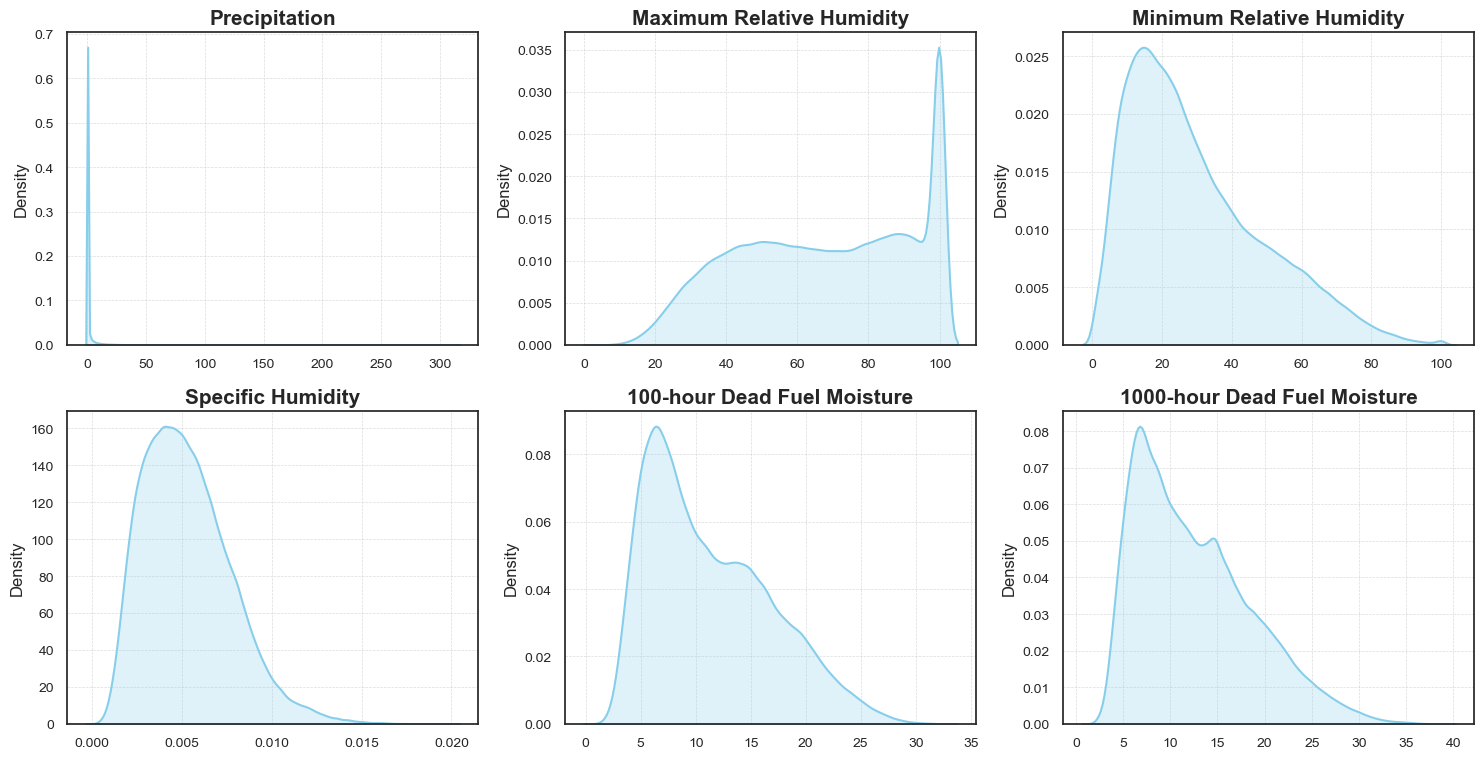

In [ ]:
grid_kde(filtered[water_supply].drop(columns='Target'))

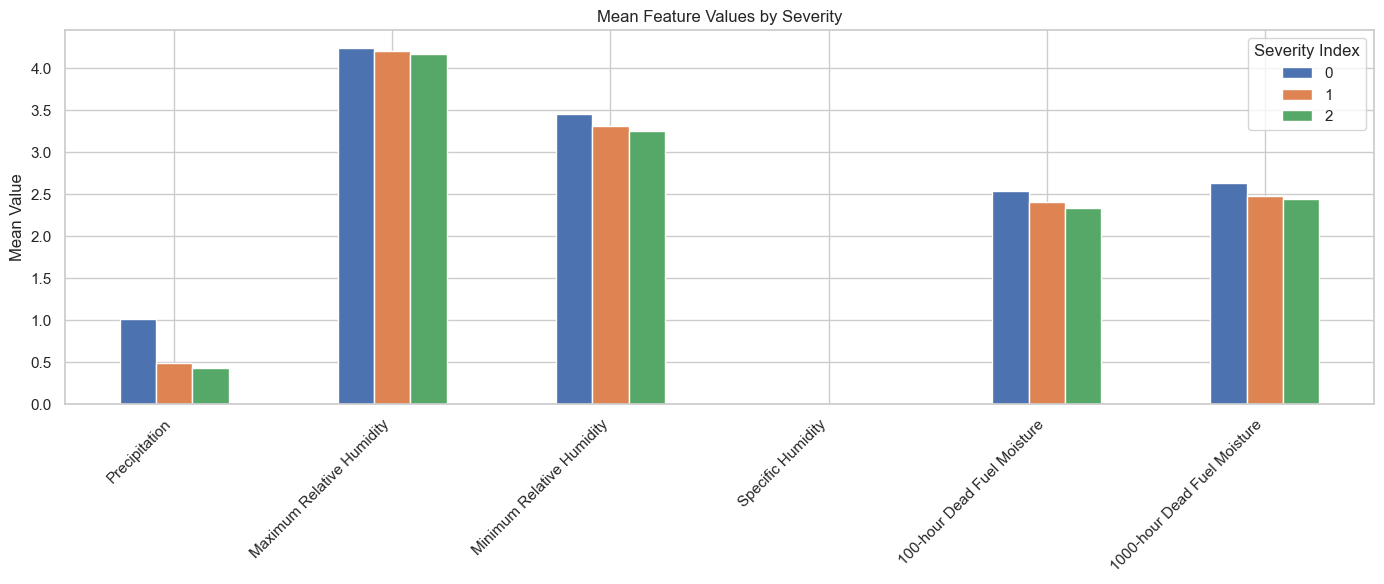

In [14]:
bar_group(filtered[water_supply])

### 3.2 Water Supply Correlation Analysis

- **Inverse Relationship with Fire Severity**  
  Both precipitation and relative humidity indicators are **negatively correlated** with the categorical fire risk index. This aligns with domain expectations—**drier and less humid conditions correspond to higher wildfire severity**.

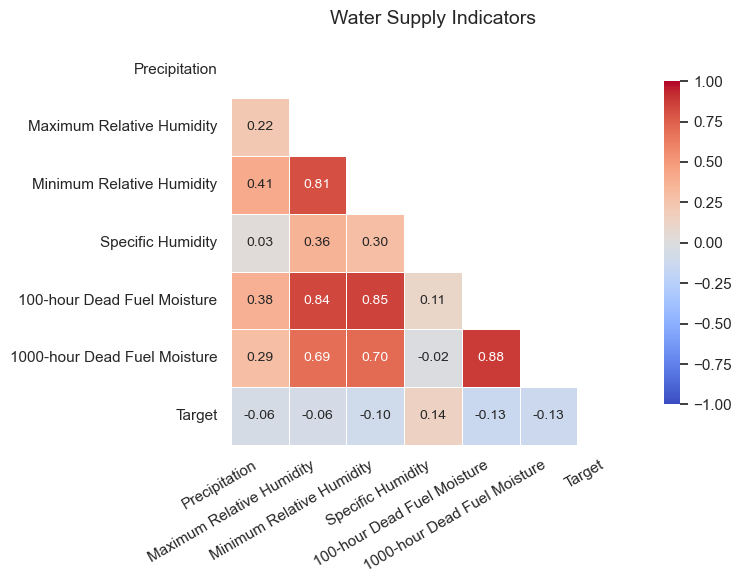

In [15]:
correlation_map(filtered[water_supply],'Water Supply Indicators')

---

## 4. Water Supply Indexes

In [ ]:
water_supply_indexes = ["Standardized Precipitation Index 30-Day",
    "Standardized Precipitation Index 180-Day",
    "Standardized Precipitation Evapotranspiration Index 30-Day",
    "Standardized Precipitation Evapotranspiration Index 90-Day",
    "Standardized Precipitation Evapotranspiration Index 180-Day",
    "Palmer Drought Severity Index",
                       'Target']

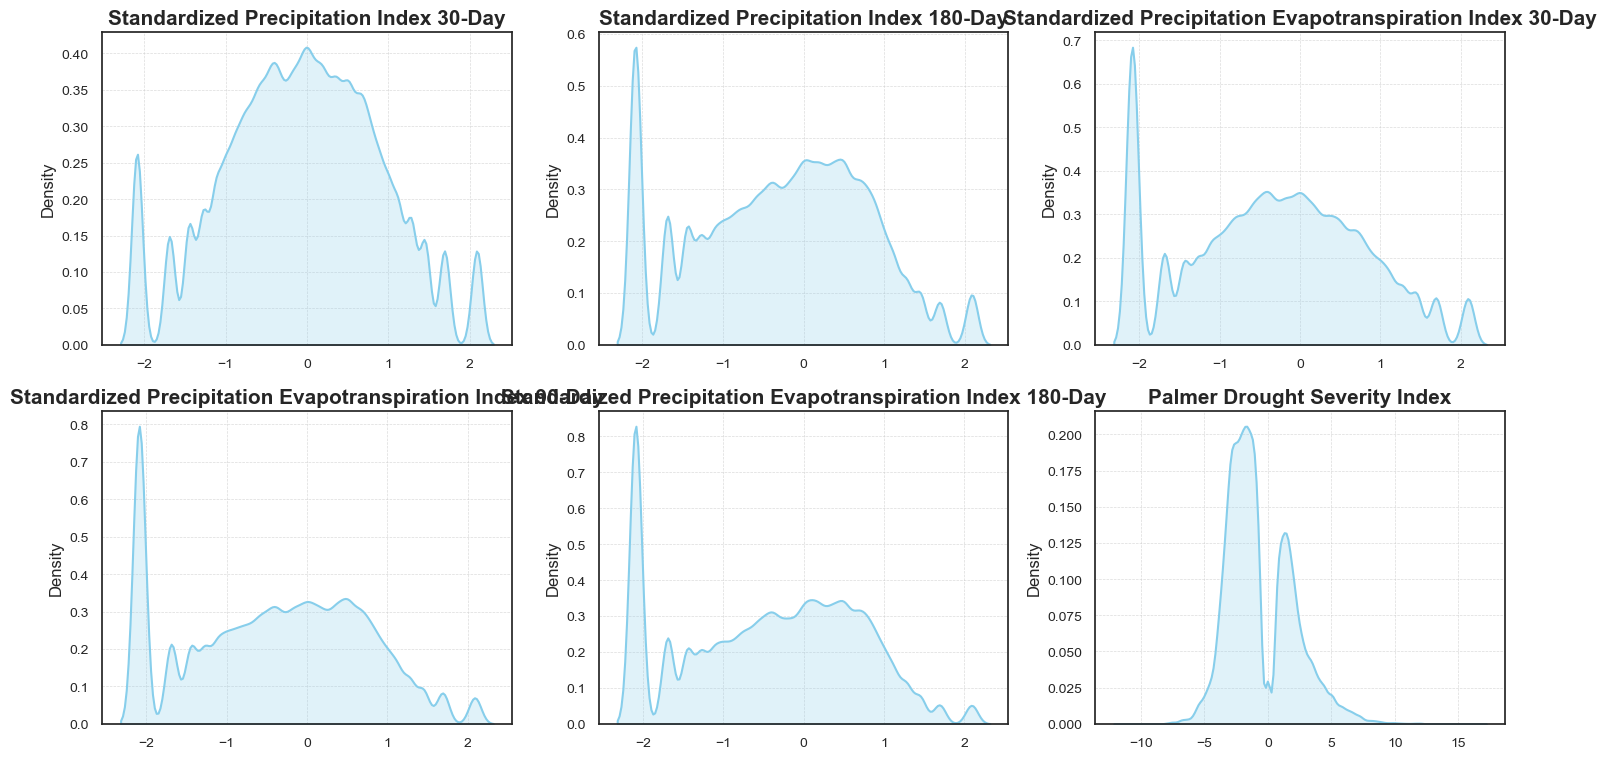

In [ ]:
grid_kde(filtered[water_supply_indexes].drop(columns='Target'))

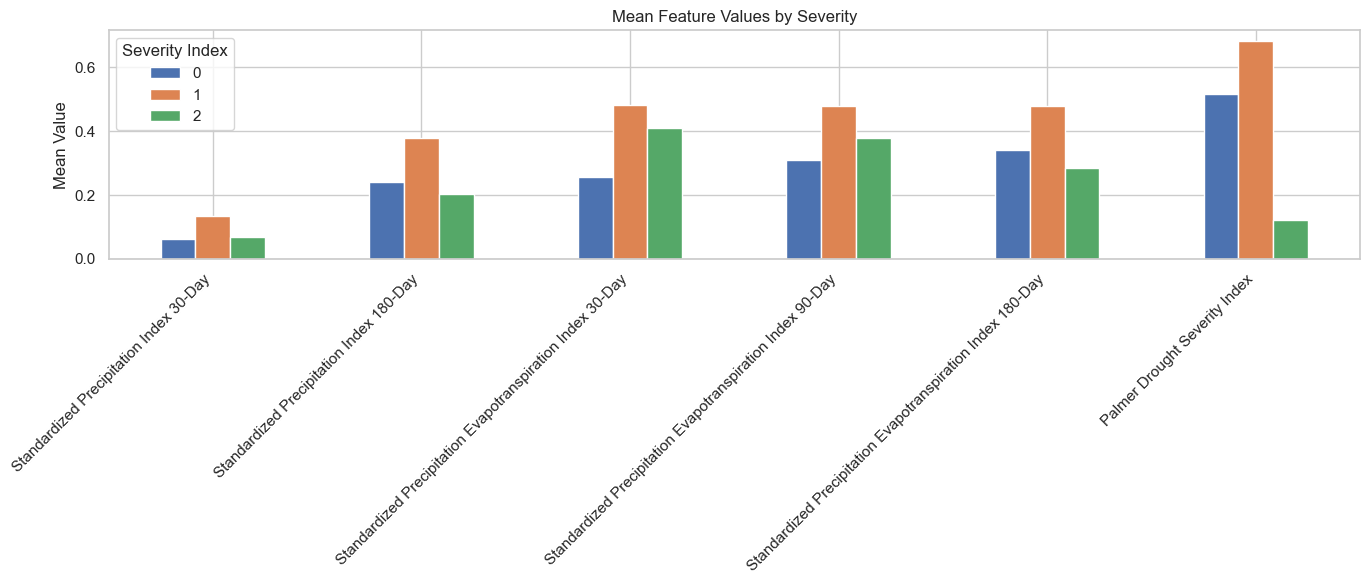

In [17]:
bar_group(filtered[water_supply_indexes])

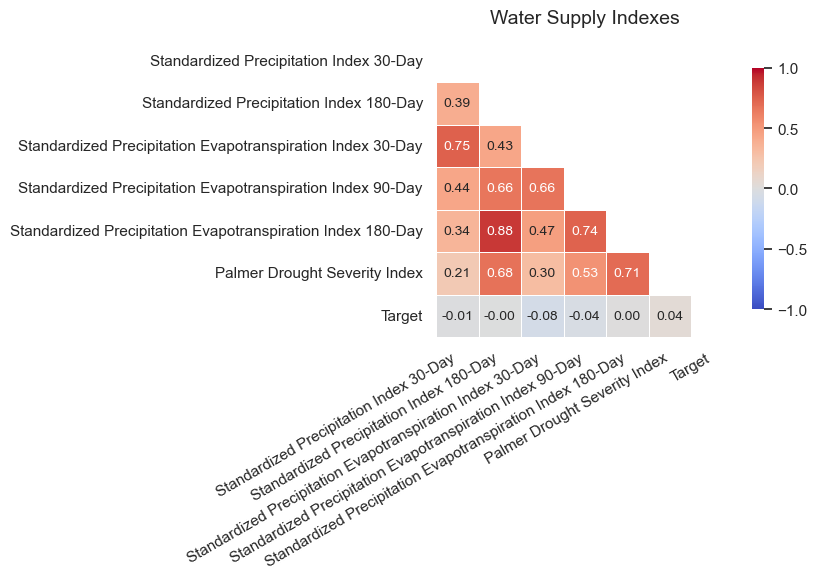

In [18]:
correlation_map(filtered[water_supply_indexes],'Water Supply Indexes')

## 5. Fire Danger

In [ ]:
fire_danger = [
    "Burning Index",
    "Energy Release Component",
    'Target']

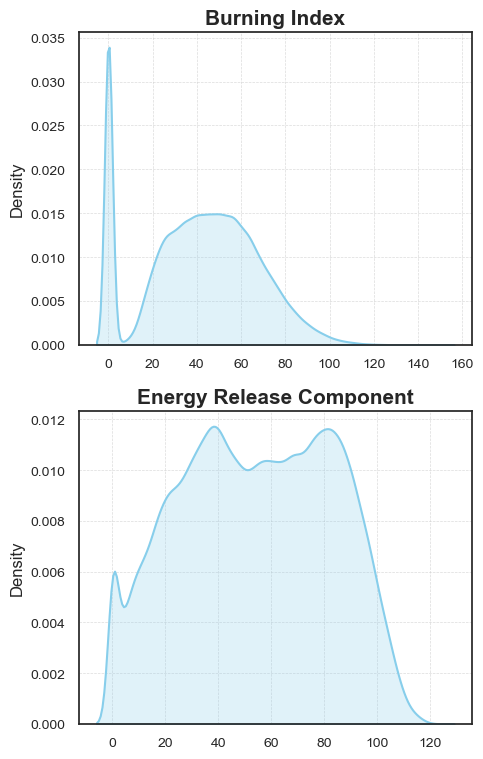

In [ ]:
grid_kde(filtered[fire_danger].drop(columns='Target'))

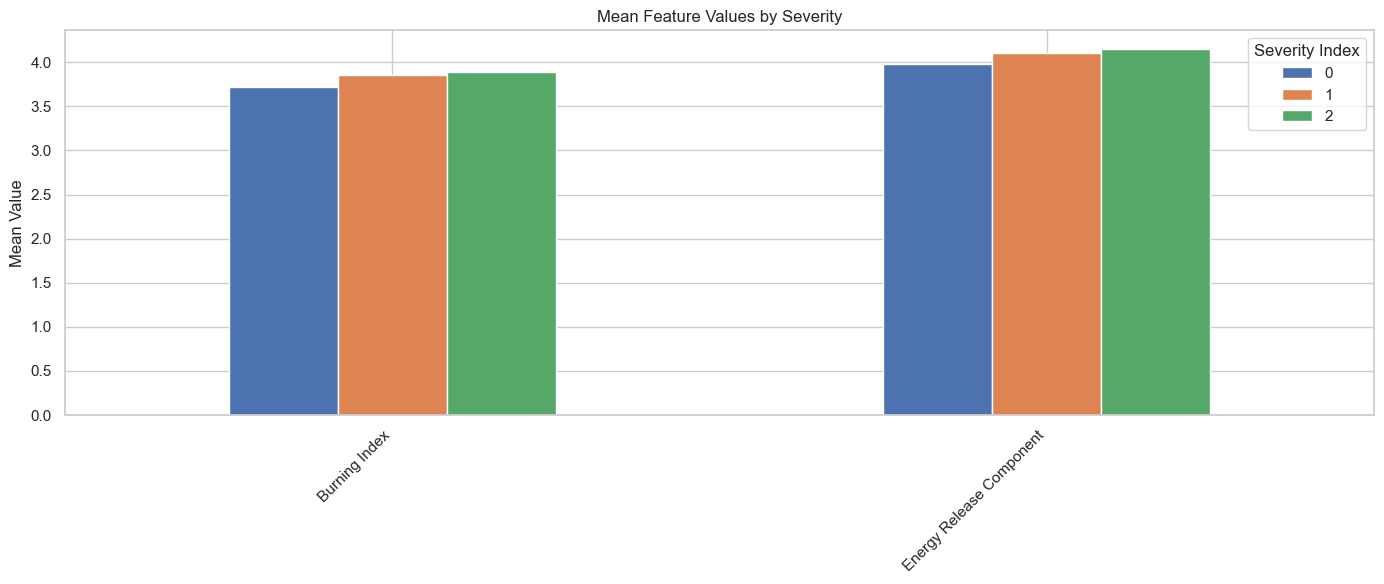

In [20]:
bar_group(filtered[fire_danger])

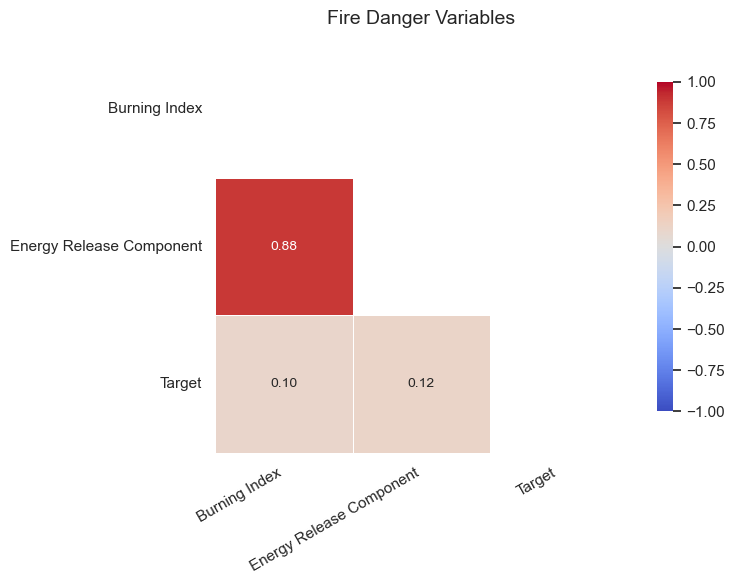

In [21]:
correlation_map(filtered[fire_danger],'Fire Danger Variables')

## 6. Social Variables

In [ ]:
Social = ['total_housing', 'total_population',
       'housing_density', 'population_density', 'median_income','Target']

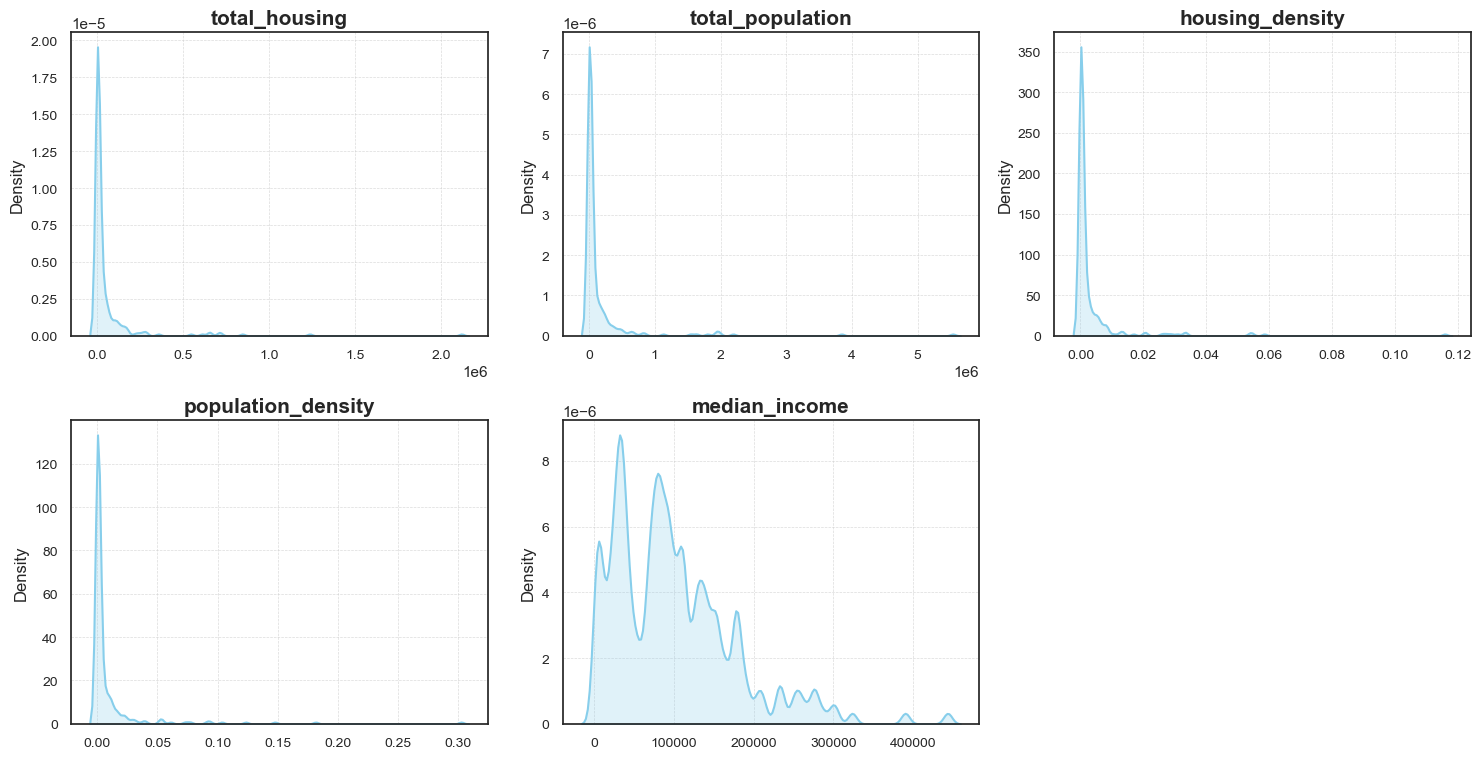

In [22]:
grid_kde(filtered[Social].drop(columns='Target'))

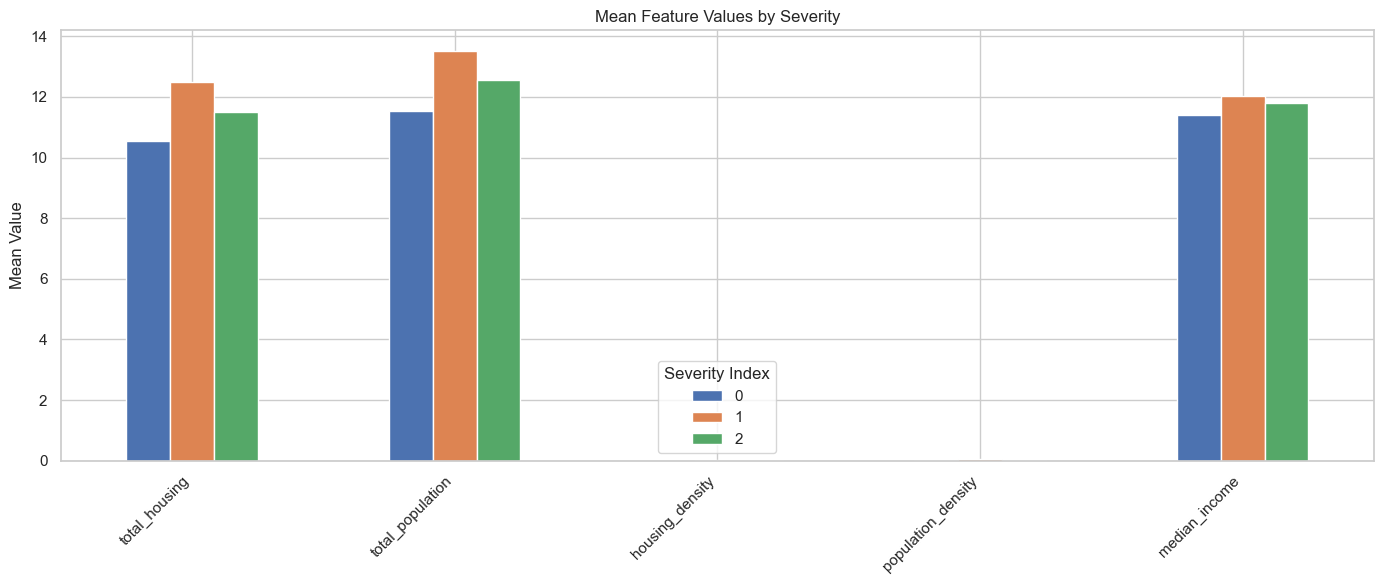

In [23]:
bar_group(filtered[Social])

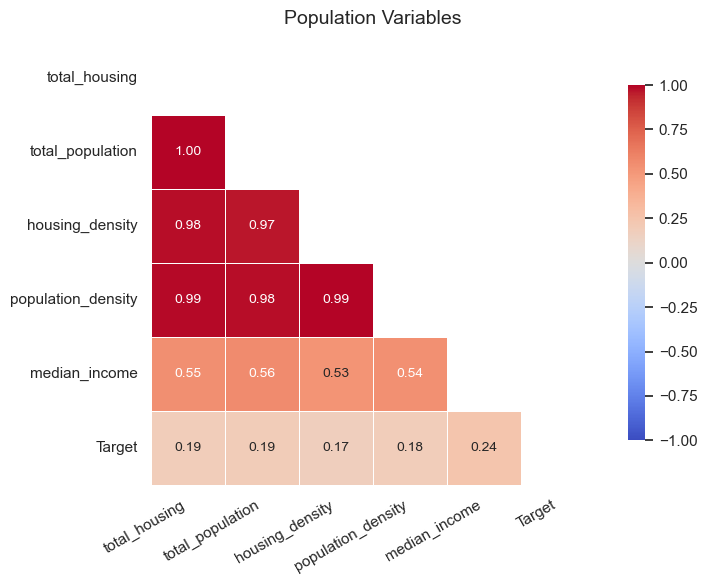

In [24]:
correlation_map(filtered[Social],'Population Variables')

## 7. Temporal Variables

In [ ]:
Temp = ['Season','2-Year Avg Fires','Month','Target']

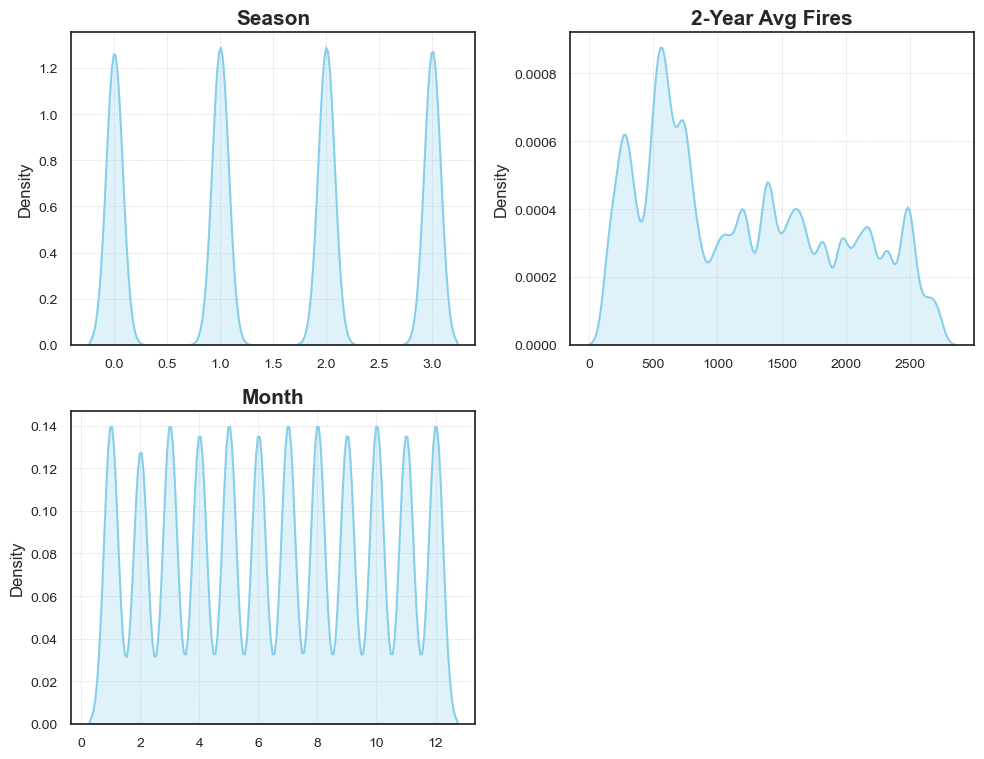

In [ ]:
grid_kde(filtered[Temp].drop(columns='Target'))

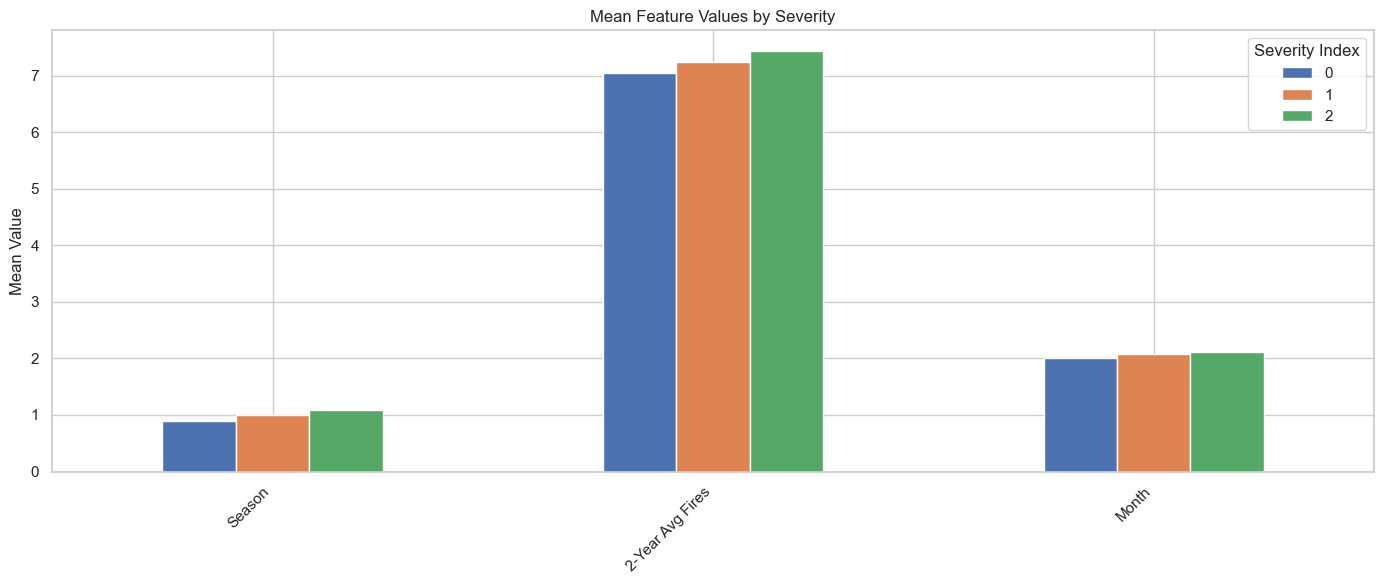

In [26]:
bar_group(filtered[Temp])

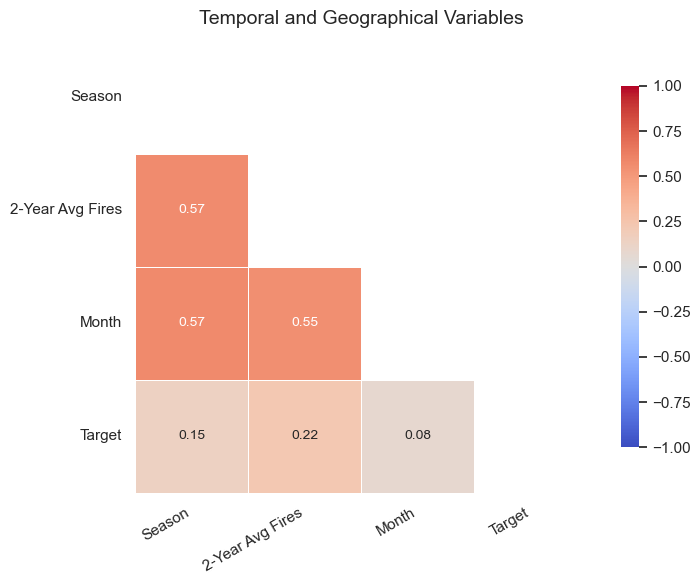

In [27]:
correlation_map(filtered[Temp],'Temporal and Geographical Variables')

## Elevation

In [ ]:
Elevation = ['elevation_range', 'elevation_mean',
       'elevation_std', 'slope_max', 'slope_range', 'slope_mean', 'slope_std',
       'northness_mean', 'eastness_mean','Target']

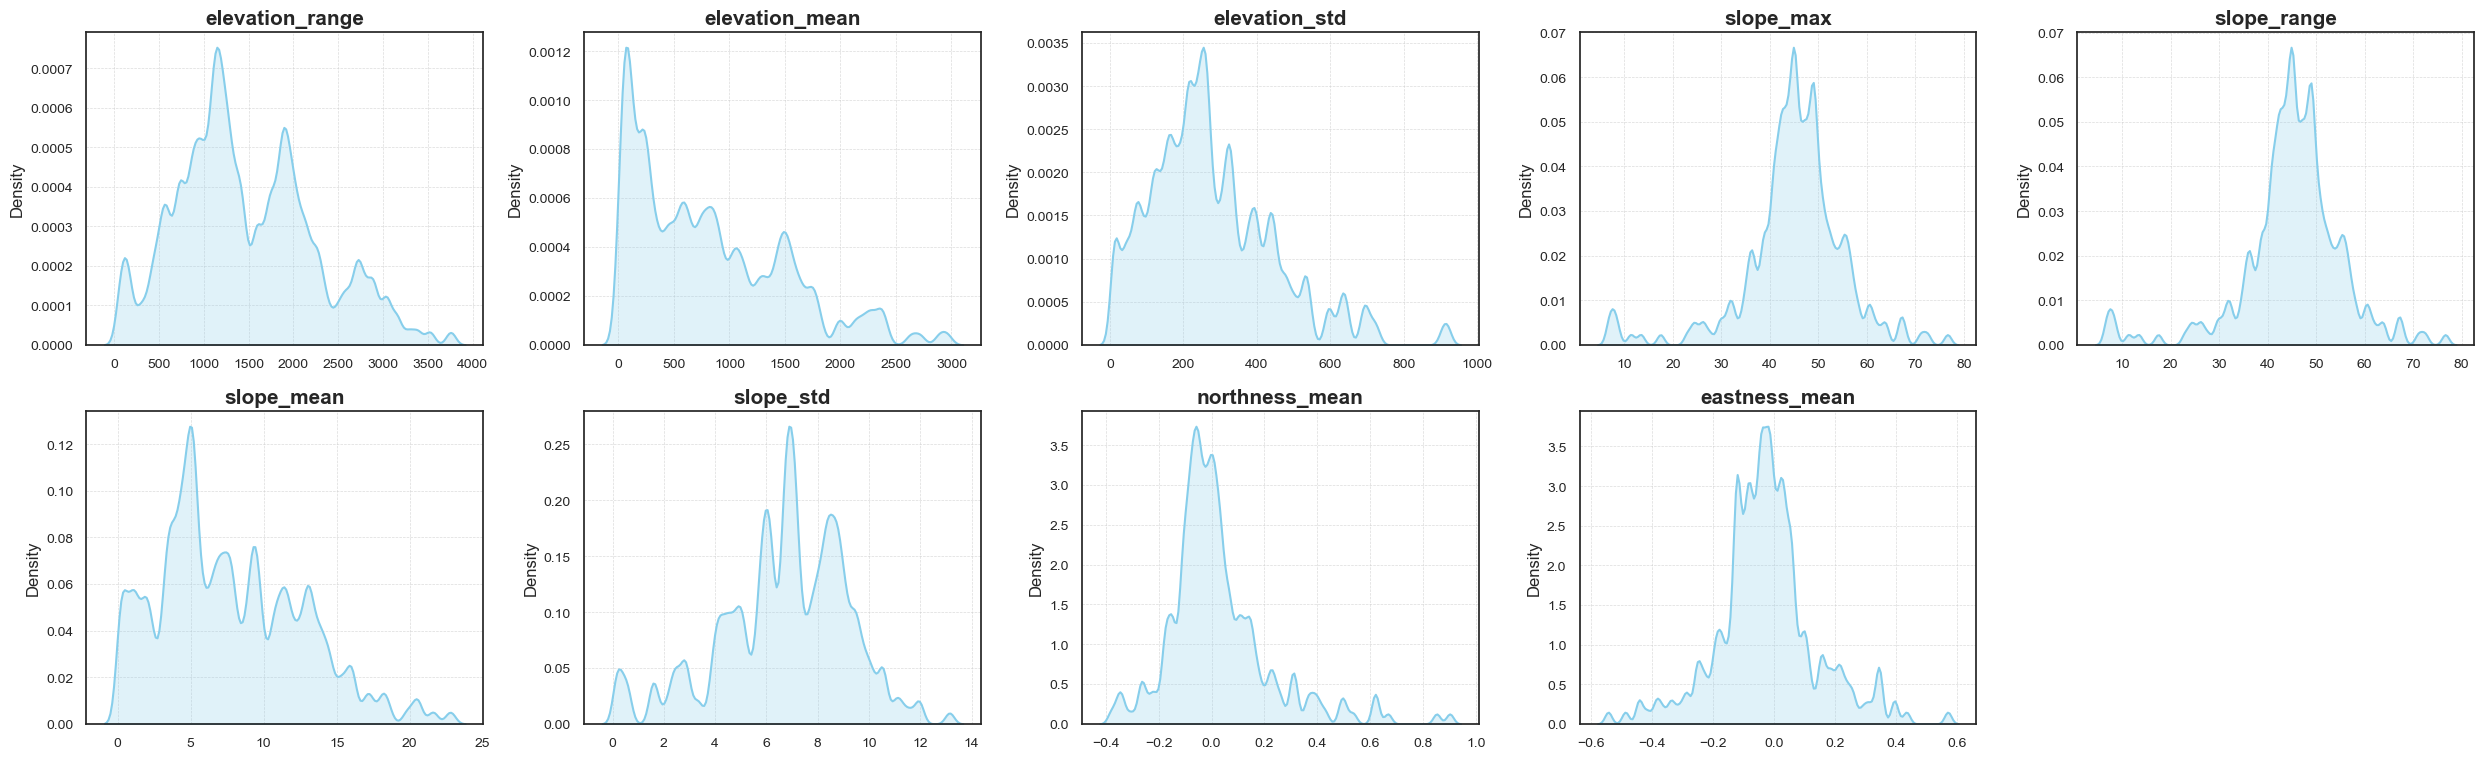

In [28]:
grid_kde(filtered[Elevation].drop(columns='Target'))

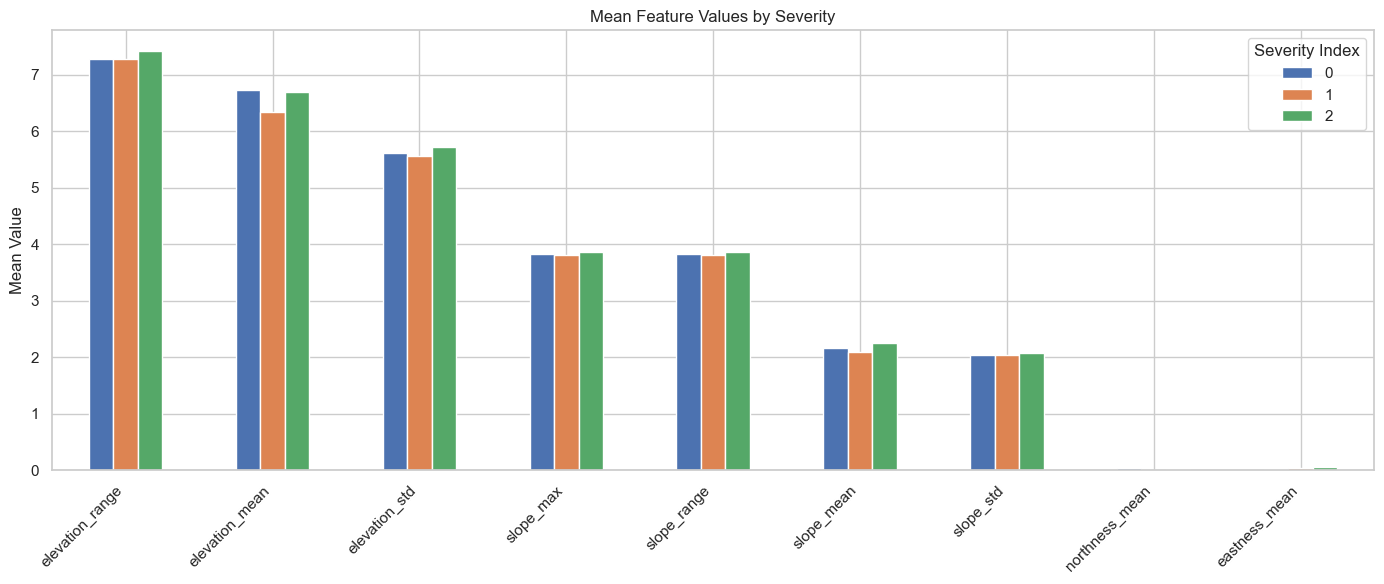

In [29]:
bar_group(filtered[Elevation])

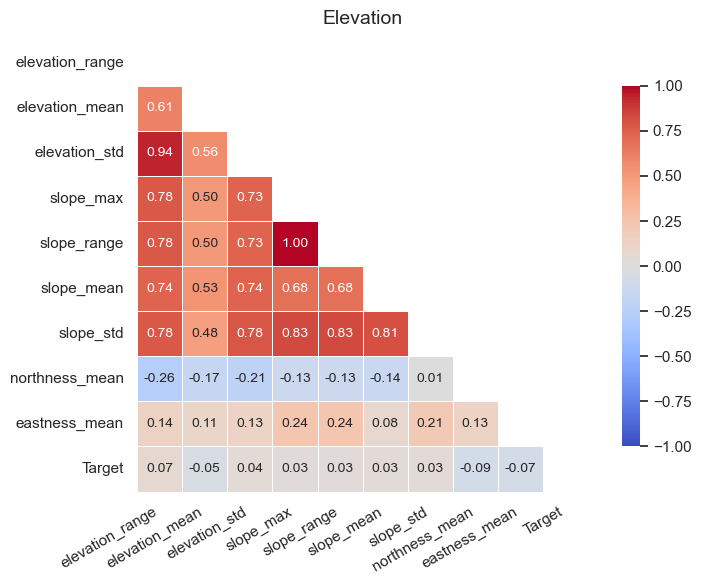

In [30]:
correlation_map(filtered[Elevation],'Elevation')

## WUI

In [ ]:
WUI = ['influence_zone', 'interface_zone', 'intermix_zone','Target']

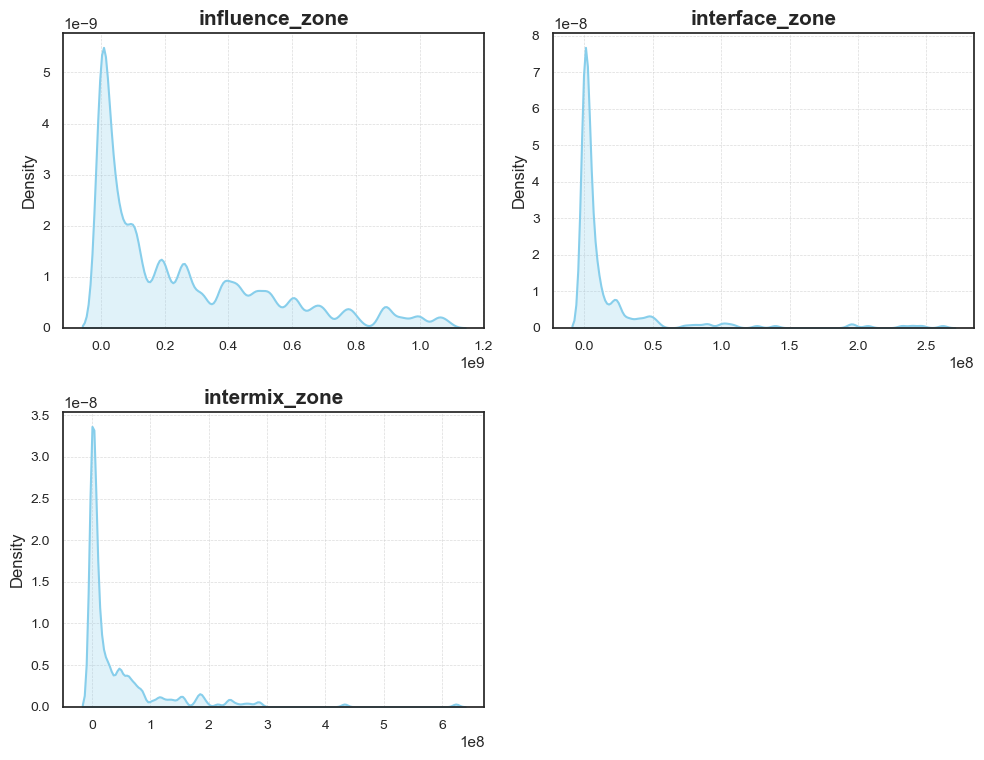

In [31]:
grid_kde(filtered[WUI].drop(columns='Target'))

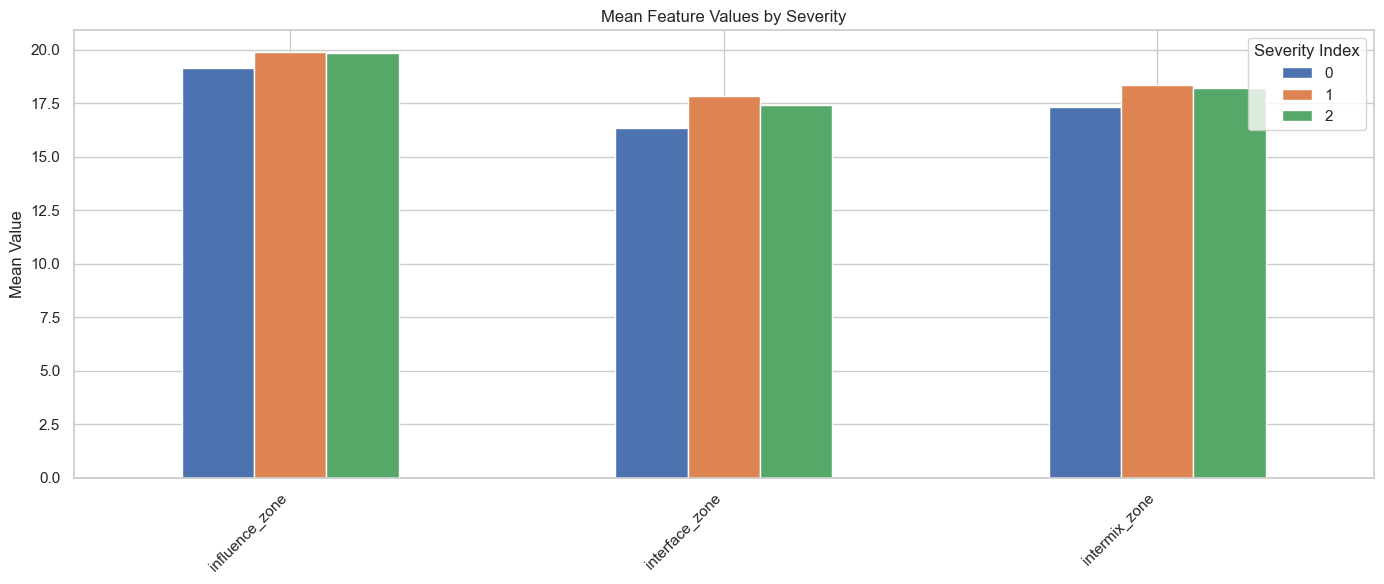

In [32]:
bar_group(filtered[WUI])

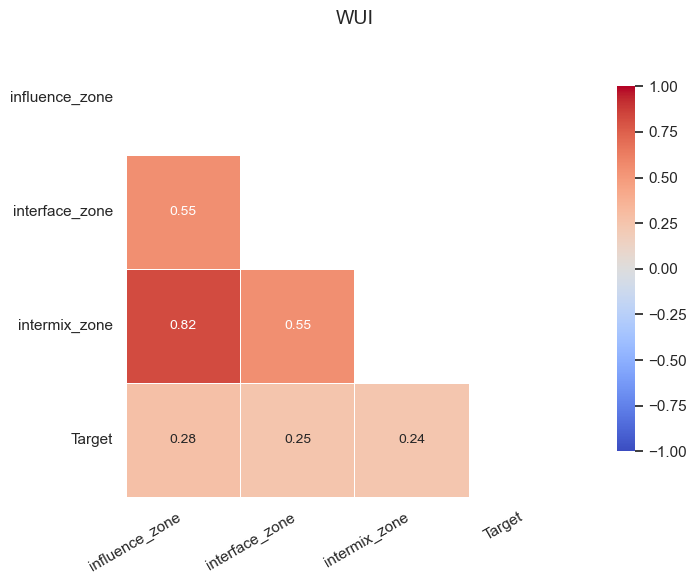

In [33]:
correlation_map(filtered[WUI],'WUI')

## Ecological

In [ ]:
Eco = ['province_code', 'dominant_province_percent',
       'sum_province_area', 'section_code', 'sum_section_area',
       'dominant_section_percent','Target']

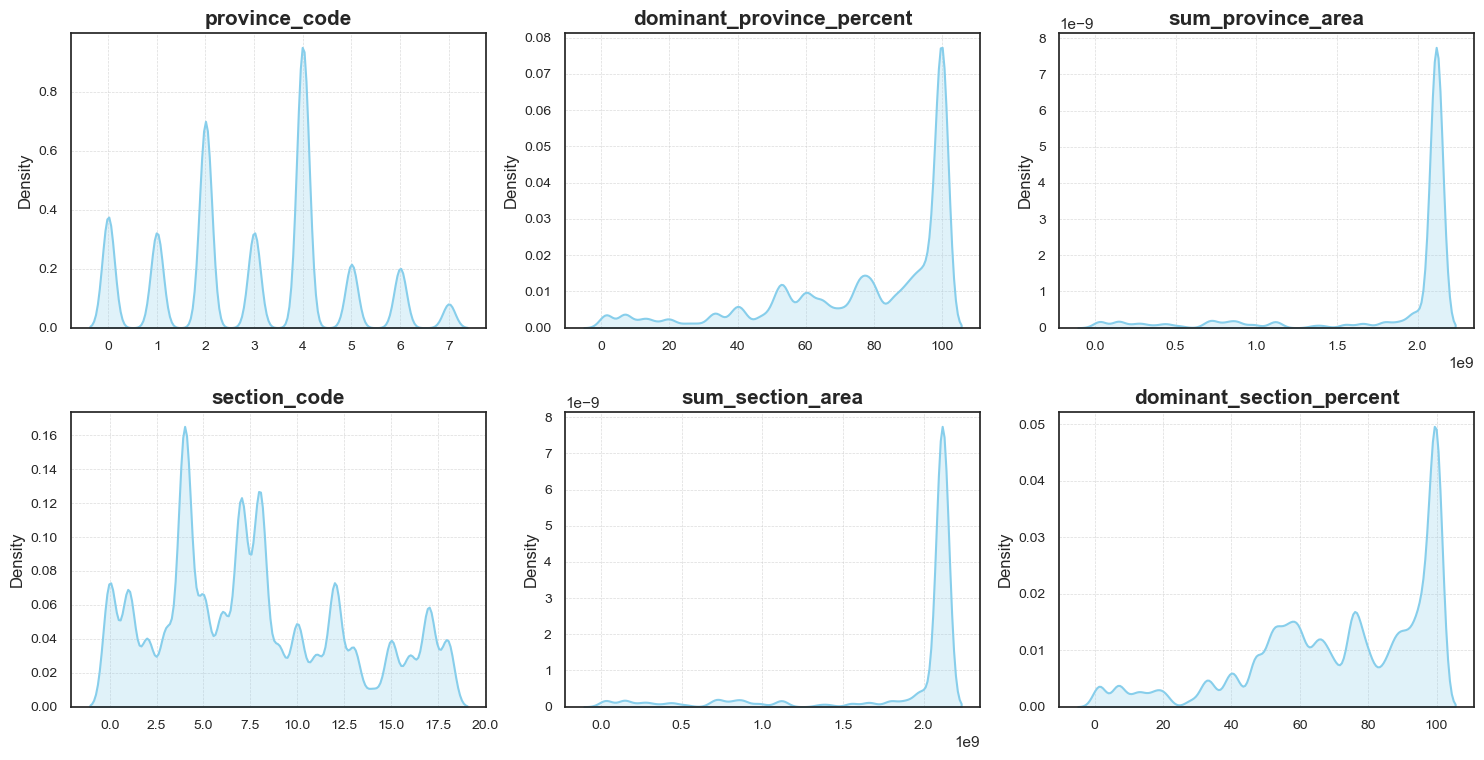

In [34]:
grid_kde(filtered[Eco].drop(columns='Target'))

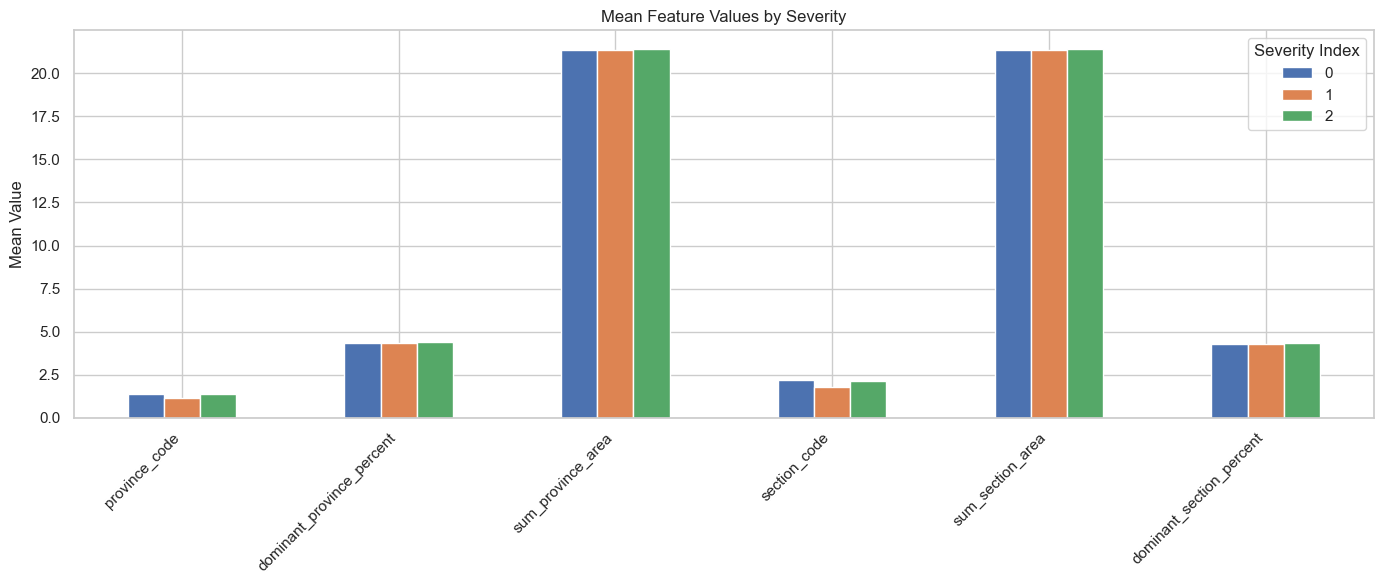

In [35]:
bar_group(filtered[Eco])

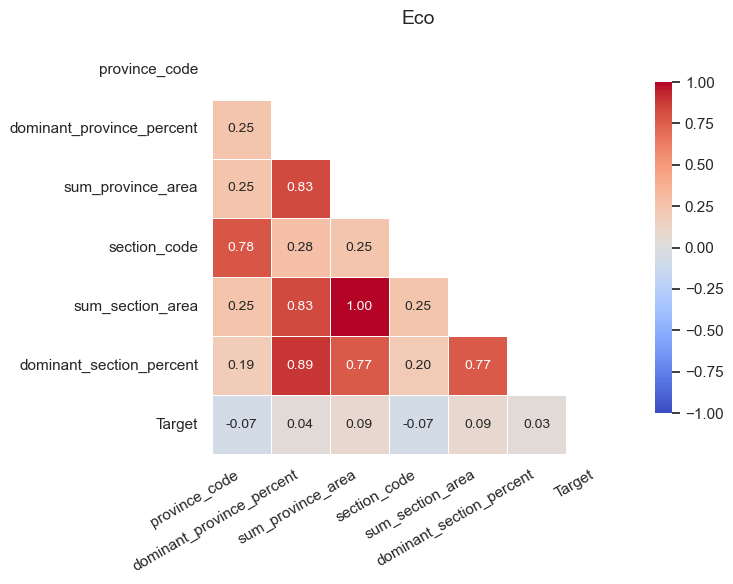

In [36]:
correlation_map(filtered[Eco],'Eco')

## Land Cover

In [ ]:
Land = ['forest_percent','developed_percent', 'other_percent', 'shrub_grass_percent',
       'wetlands_percent','Target']

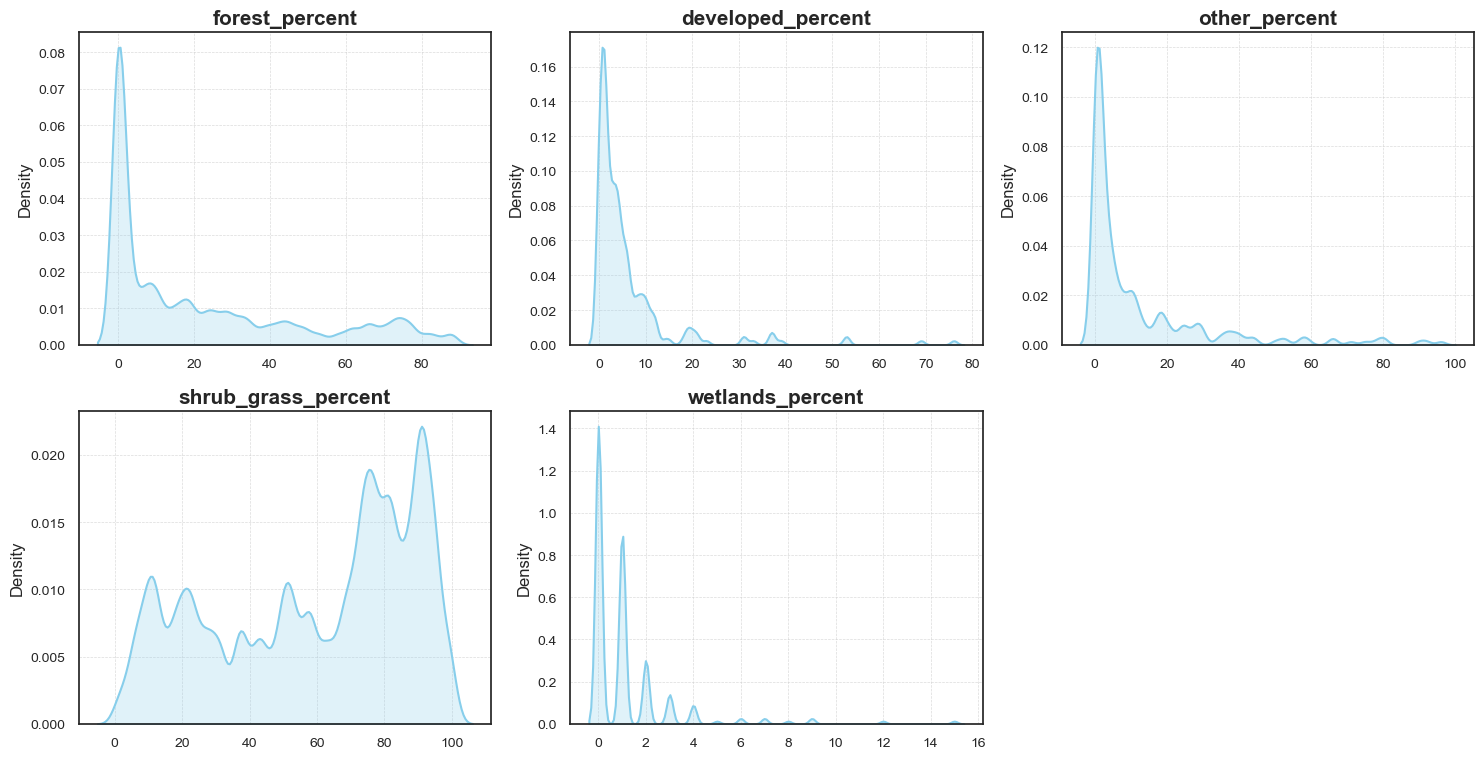

In [37]:
grid_kde(filtered[Land].drop(columns='Target'))

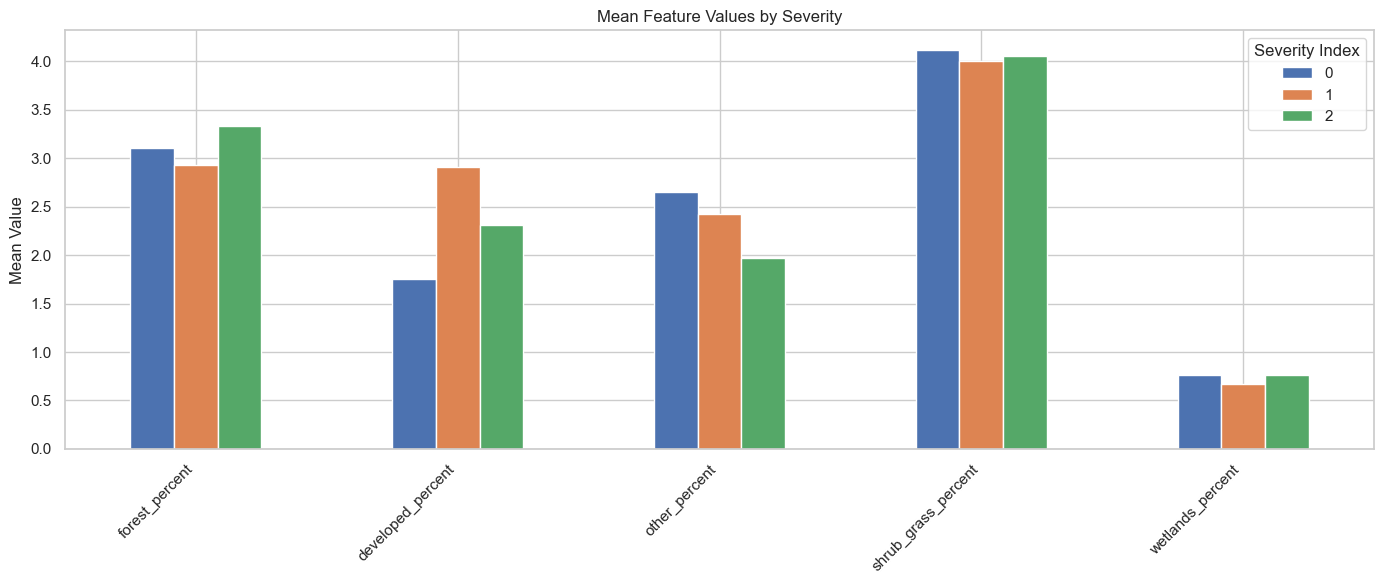

In [38]:
bar_group(filtered[Land])

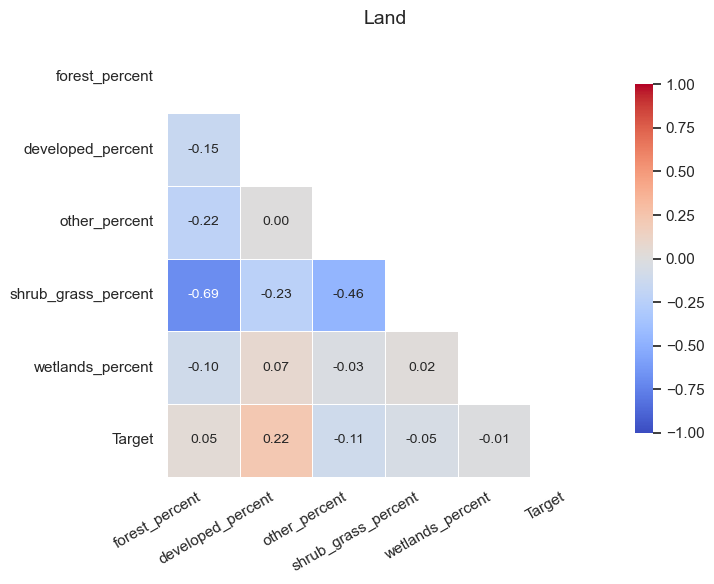

In [39]:
correlation_map(filtered[Land],'Land')

---

In [40]:
X = X.drop(columns='Target')

## 8. Export File

In [41]:
X.to_csv('../data/processed/X.csv', index=False)
y.to_csv('../data/processed/y.csv', index=False)
details.to_csv('../data/processed/details.csv', index=False)

pal_X.to_csv('../data/processed/pal_X.csv', index=False)
pal_details.to_csv('../data/processed/pal_details.csv', index=False)
pal_y.to_csv('../data/processed/pal_y.csv', index=False)
print("All datasets saved successfully to ../data/processed/")

All datasets saved successfully to ../data/processed/
